**Goal:** train a network that would otherwise refuse to train. You will watch a deep net's signal
**vanish**, then bring it back to life with the right **initialization** and **activation**; race three
**optimizers**; and use **dropout** and **batch normalization** to fight overfitting and stabilize
training. Every demo runs in seconds on CPU on small synthetic data -- the point is the *mechanism*,
not the scale (image-scale training is L18; full hyperparameter tuning is the CDAT 4013 lab). Pairs
with the concept note [Training Deep Networks](l17_concept_training_deep_networks.qmd).

> **Previously:** L16 -- Backpropagation & Autodiff (we built the gradient engine)  |  **Next:** L18 -- Convolutional Neural Networks

> This page is the read-only view. To run the lab, open the notebook
> (`l17_lab_training_deep_networks.ipynb`) -- in Colab via the badge on the concept page, or locally.

## Scenario

We can now build a network of any depth (L14-L15) and compute its gradients exactly (L16). But depth
is treacherous: stack enough layers and backprop's long product of local derivatives drives the
gradient to the lower layers toward zero, and the net never learns. This lab is the engineer's repair
kit -- initialization, activations, optimizers, learning rate, dropout, and batch normalization -- each
applied to a small net so you can see exactly what it fixes.

## Setup

Two cells: the first installs, the second imports, seeds, and defines two helpers we reuse all lab.

In [1]:
# Setup, cell 1 of 2 -- INSTALL (run once; Colab wipes installs when it resets on open)
# Colab already ships numpy, scikit-learn, matplotlib and torch, so this is effectively a no-op there.
%pip install -q numpy scikit-learn matplotlib torch
# local, in a terminal (not in the notebook):  uv add numpy scikit-learn matplotlib torch

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Setup, cell 2 of 2 -- IMPORTS + SEEDS + HELPERS (safe to re-run without re-installing)
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42); torch.manual_seed(42)

def make_split(X, y, seed=42):
    """Stratified 75/25 split, standardized (scaler fit on train only), returned as tensors."""
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.25, random_state=seed, stratify=y)
    sc = StandardScaler().fit(Xtr)
    Xtr, Xte = sc.transform(Xtr), sc.transform(Xte)
    t = lambda a, d: torch.tensor(a, dtype=d)
    return t(Xtr, torch.float32), t(ytr, torch.long), t(Xte, torch.float32), t(yte, torch.long)

def deep_net(activation, in_dim=2, depth=6, width=30, he_init=False, dropout=0.0, batchnorm=False):
    """A `depth`-hidden-layer MLP; optional He init, BatchNorm, and Dropout."""
    layers, d = [], in_dim
    for _ in range(depth):
        linear = nn.Linear(d, width)
        if he_init:
            nn.init.kaiming_normal_(linear.weight, nonlinearity="relu")
            nn.init.zeros_(linear.bias)
        layers.append(linear)
        if batchnorm:
            layers.append(nn.BatchNorm1d(width))
        layers.append(activation())
        if dropout > 0:
            layers.append(nn.Dropout(dropout))
        d = width
    layers.append(nn.Linear(d, 2))
    return nn.Sequential(*layers)

def train(model, data, optimizer, epochs=300):
    """Full-batch training; returns the per-epoch loss curve and final train/test accuracy."""
    Xtr, ytr, Xte, yte = data
    loss_fn = nn.CrossEntropyLoss()
    curve = []
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        loss = loss_fn(model(Xtr), ytr)
        loss.backward()
        optimizer.step()
        curve.append(loss.item())
    model.eval()
    with torch.no_grad():
        tr = (model(Xtr).argmax(1) == ytr).float().mean().item()
        te = (model(Xte).argmax(1) == yte).float().mean().item()
    return curve, tr, te

Xm, ym = make_moons(n_samples=1000, noise=0.20, random_state=42)
moons = make_split(Xm, ym, seed=42)
print(f"moons: {tuple(moons[0].shape)} train / {tuple(moons[2].shape)} test")

moons: (750, 2) train / (250, 2) test


~~~text
moons: (750, 2) train / (250, 2) test
~~~

## Step 1: Watch the Signal Vanish

Before training anything, look at what depth does to a plain forward signal. Send a standard-normal
input through 20 `Linear -> ReLU` layers (no learning, just the forward pass) and measure the
activation standard deviation at the end under three weight initializations. If it collapses to 0, the
gradients flowing back will too.

In [3]:
torch.manual_seed(0)
x = torch.randn(512, 100)
print(f"input std: {x.std().item():.4f}")
for name, init in [("PyTorch default", None),
                   ("Xavier / Glorot", nn.init.xavier_uniform_),
                   ("He / Kaiming",    nn.init.kaiming_uniform_)]:
    torch.manual_seed(0)
    h = x
    for _ in range(20):
        layer = nn.Linear(100, 100, bias=False)
        if init is not None:
            init(layer.weight)
        h = torch.relu(layer(h))
    print(f"{name:16s} -> std after 20 ReLU layers: {h.std().item():.4f}")

input std: 0.9997
PyTorch default  -> std after 20 ReLU layers: 0.0000
Xavier / Glorot  -> std after 20 ReLU layers: 0.0009
He / Kaiming     -> std after 20 ReLU layers: 0.8975


~~~text
input std: 0.9997
PyTorch default  -> std after 20 ReLU layers: 0.0000
Xavier / Glorot  -> std after 20 ReLU layers: 0.0009
He / Kaiming     -> std after 20 ReLU layers: 0.8975
~~~

The signal starting at std `1.0` is **gone** after 20 layers with the default or Xavier init -- and a
dead forward signal means dead backward gradients. **He / Kaiming** init, scaled for ReLU, keeps it
alive at `0.90`. Initialization is the first thing that decides whether a deep net can train at all.
(This demo uses the `_uniform_` initializers; the `deep_net` helper below uses `kaiming_normal_`.
Uniform vs normal changes only the sampling shape, not the variance scaling that keeps the signal
alive.)

## Step 2: Cure It -- Initialization + Activation

Now train a genuinely deep net (8 hidden layers) on the two-moons data, two ways: **sigmoid + the
default init** (the 2000s recipe) versus **ReLU + He init** (the modern one). We use plain SGD so the
choice of init and activation -- not an adaptive optimizer -- decides the outcome. First we print each
net's **first-layer gradient norm** (the smoking gun), then train and compare.

The `deep_net` helper already calls `nn.init.kaiming_normal_(linear.weight, nonlinearity="relu")` when
`he_init=True` -- that one line is the entire fix.

In [4]:
def first_layer_grad_norm(model, data):
    model.train()
    loss = nn.CrossEntropyLoss()(model(data[0]), data[1])
    loss.backward()
    return model[0].weight.grad.norm().item()

step2 = {}
for tag, activation, he in [("sigmoid + default", nn.Sigmoid, False),
                            ("ReLU + He",        nn.ReLU,    True)]:
    torch.manual_seed(1)
    net = deep_net(activation, depth=8, width=30, he_init=he)
    g = first_layer_grad_norm(net, moons)
    torch.manual_seed(1)
    net = deep_net(activation, depth=8, width=30, he_init=he)
    curve, tr, te = train(net, moons, torch.optim.SGD(net.parameters(), lr=0.5), epochs=400)
    step2[tag] = curve
    print(f"{tag:18s}: grad-norm {g:.6f}  loss {curve[0]:.3f} -> {curve[-1]:.3f}  train/test {tr:.3f}/{te:.3f}")

sigmoid + default : grad-norm 0.000000  loss 0.693 -> 0.693  train/test 0.520/0.516


ReLU + He         : grad-norm 0.085034  loss 0.767 -> 0.066  train/test 0.977/0.988


~~~text
sigmoid + default : grad-norm 0.000000  loss 0.693 -> 0.693  train/test 0.520/0.516
ReLU + He         : grad-norm 0.085034  loss 0.767 -> 0.066  train/test 0.977/0.988
~~~

The sigmoid net's first-layer gradient is `0.000000` -- the signal never reaches the bottom -- so its
loss is frozen at `0.693` (that is `ln 2`, the loss of pure guessing) and its accuracy stays at chance
(`0.52`). The ReLU + He net has a healthy gradient (`0.085`), its loss falls to `0.066`, and it reaches
`0.988` test accuracy. Same depth, same data, same optimizer -- the cure is initialization + activation.

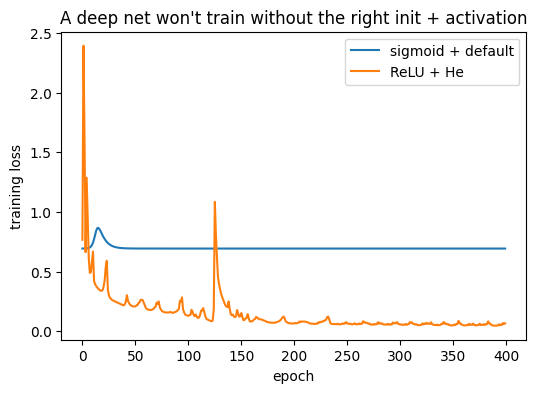

In [5]:
plt.figure(figsize=(6, 4))
for tag, curve in step2.items():
    plt.plot(curve, label=tag)
plt.xlabel("epoch"); plt.ylabel("training loss"); plt.legend()
plt.title("A deep net won't train without the right init + activation")
plt.show()

## Step 3: Better Optimizers

With the net now trainable (ReLU + He), the **optimizer** decides how fast. Train the same 4-hidden-layer
net three ways -- plain SGD, SGD with momentum, and Adam -- from identical starting weights, and compare
the loss curves.

In [6]:
step3 = {}
for tag, make_opt in [("SGD",          lambda p: torch.optim.SGD(p, lr=0.1)),
                      ("SGD+momentum", lambda p: torch.optim.SGD(p, lr=0.1, momentum=0.9)),
                      ("Adam",         lambda p: torch.optim.Adam(p, lr=0.01))]:
    torch.manual_seed(2)
    net = deep_net(nn.ReLU, depth=4, width=30, he_init=True)
    curve, tr, te = train(net, moons, make_opt(net.parameters()), epochs=150)
    step3[tag] = curve
    print(f"{tag:13s}: final loss {curve[-1]:.4f}  train/test {tr:.3f}/{te:.3f}")

SGD          : final loss 0.1304  train/test 0.960/0.968


SGD+momentum : final loss 0.0558  train/test 0.976/0.988


Adam         : final loss 0.0440  train/test 0.984/0.980


~~~text
SGD          : final loss 0.1304  train/test 0.960/0.968
SGD+momentum : final loss 0.0558  train/test 0.976/0.988
Adam         : final loss 0.0440  train/test 0.984/0.980
~~~

Momentum (a velocity over past gradients) more than halves SGD's final loss; Adam (momentum + a
per-parameter adaptive step size) does best with no extra tuning. This is why Adam is the default
first choice.

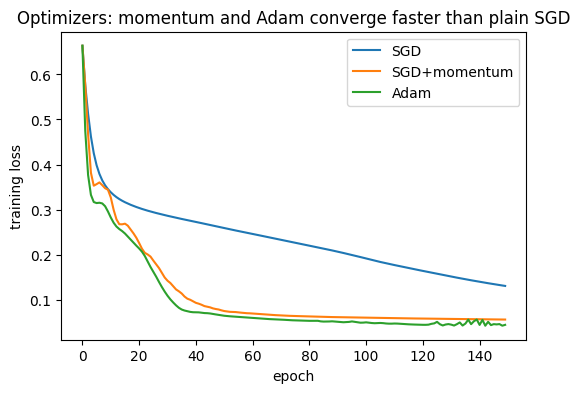

In [7]:
plt.figure(figsize=(6, 4))
for tag, curve in step3.items():
    plt.plot(curve, label=tag)
plt.xlabel("epoch"); plt.ylabel("training loss"); plt.legend()
plt.title("Optimizers: momentum and Adam converge faster than plain SGD")
plt.show()

## Step 4: Dropout vs Overfitting -- completion problem

Switch to a harder, higher-dimensional set (20 features) where a wide net has the capacity to
**memorize**. Train it with no regularization first and watch it overfit -- train accuracy `1.000`,
test far behind.

In [8]:
Xc, yc = make_classification(n_samples=300, n_features=20, n_informative=8, n_redundant=4,
                             n_clusters_per_class=2, class_sep=0.8, flip_y=0.05, random_state=0)
clf = make_split(Xc, yc, seed=0)

torch.manual_seed(3)
net = deep_net(nn.ReLU, in_dim=20, depth=3, width=256, he_init=True, dropout=0.0)
curve, tr, te = train(net, clf, torch.optim.Adam(net.parameters(), lr=0.001), epochs=600)
print(f"no dropout : train/test {tr:.3f}/{te:.3f}  gap {tr-te:.3f}")

no dropout : train/test 1.000/0.840  gap 0.160


~~~text
no dropout : train/test 1.000/0.840  gap 0.160
~~~

Now add **dropout** to regularize it. `deep_net` inserts an `nn.Dropout(p)` after each activation when
you pass `dropout=p`. Complete the dropout probability (try `0.5`) and compare:

In [9]:
# Uncomment and complete the dropout probability, then compare to the run above:
# torch.manual_seed(3)
# net = deep_net(nn.ReLU, in_dim=20, depth=3, width=256, he_init=True, dropout=____)
# curve, tr, te = train(net, clf, torch.optim.Adam(net.parameters(), lr=0.001), epochs=600)
# print(f"with dropout: train/test {tr:.3f}/{te:.3f}  gap {tr-te:.3f}")

<details><summary>Expected Output</summary>

~~~text
with dropout: train/test 1.000/0.880  gap 0.120
~~~

The blank is `0.5`. Dropout randomly zeros half the activations on every training step, so no unit can
rely on any other -- the net spreads its bets and generalizes better. Test accuracy rises from `0.840`
to `0.880` and the train-test gap shrinks from `0.160` to `0.120`. Note that `train()` activates
dropout and the final `model.eval()` (inside `train`) switches it off, so the test accuracy uses the
full network.
</details>

## Your Turn

### Exercise 1 -- The learning-rate sweep

The learning rate is the single most important hyperparameter. On the moons net (4 hidden, ReLU + He),
train with Adam at `lr` in `[10, 1, 0.01, 0.0001]` for 150 epochs and read which diverges, which
crawls, and which wins. Print the final loss and train/test accuracy for each.

**Hint:** loop over the learning rates; re-seed (`torch.manual_seed(4)`) and rebuild the net each time
so only the learning rate changes; reuse `train(net, moons, torch.optim.Adam(net.parameters(), lr=lr), epochs=150)`.

In [10]:
# TODO: your code here

<details><summary>Expected Output</summary>

~~~text
lr=10.0   : final loss 4.7964  train/test 0.736/0.716
lr=1.0    : final loss 0.4204  train/test 0.799/0.780
lr=0.01   : final loss 0.0480  train/test 0.981/0.992
lr=0.0001 : final loss 0.4205  train/test 0.845/0.900
~~~

The solution loops over the four rates, re-seeding and rebuilding the net each time so only `lr`
changes: `for lr in [10.0, 1.0, 0.01, 0.0001]:` then `torch.manual_seed(4)`,
`net = deep_net(nn.ReLU, depth=4, width=30, he_init=True)`, and
`train(net, moons, torch.optim.Adam(net.parameters(), lr=lr), epochs=150)`. `lr=10` is so large the
loss diverges (ends at `4.80`, accuracy near chance); `lr=0.0001` is so small it barely moves in 150
epochs (`0.42`); `lr=0.01` is in the sweet spot (test `0.992`). When a net will not train, sweep the
learning rate by orders of magnitude first.
</details>

### Exercise 2 -- Add batch normalization

Insert batch normalization into the deep (8-hidden) net and compare it to the plain version. `deep_net`
adds an `nn.BatchNorm1d` after each linear layer when you pass `batchnorm=True`. Train both with Adam
(`lr=0.01`) for 200 epochs and compare the final loss and test accuracy.

**Hint:** loop over `batchnorm in [False, True]`; re-seed (`torch.manual_seed(5)`) and rebuild with
`deep_net(nn.ReLU, depth=8, width=30, he_init=True, batchnorm=batchnorm)` each time.

In [11]:
# TODO: your code here

<details><summary>Expected Output</summary>

~~~text
plain         : final loss 0.0963  train/test 0.967/0.968
with BatchNorm: final loss 0.0004  train/test 1.000/0.984
~~~

The solution loops `for tag, bn in [("plain        ", False), ("with BatchNorm", True)]:`, then
re-seeds with `torch.manual_seed(5)`, rebuilds via
`deep_net(nn.ReLU, depth=8, width=30, he_init=True, batchnorm=bn)`, and trains with
`torch.optim.Adam(net.parameters(), lr=0.01)` for 200 epochs.
Batch normalization keeps each layer's activations well-conditioned, so the deep net drives its loss
far lower (`0.0004` vs `0.0963`) and fits a touch better. Like dropout, BatchNorm behaves differently
in `train()` (batch statistics) and `eval()` (running statistics) -- the `train` helper already handles
both modes for you.
</details>

## Summary

- **Unstable gradients** are the core obstacle to depth: backprop's long product of local derivatives
  **vanishes** (factors < 1) or **explodes** (factors > 1). A deep sigmoid net's first-layer gradient
  was `0.000000` and its loss froze at `0.693` (chance).
- **Initialization + activation** are the first cure: He / Kaiming init with ReLU keeps the signal
  alive (std `0.90` vs `0.00` after 20 layers) and lets the same deep net reach `0.988`.
- **Optimizers** decide speed: momentum then Adam cut the final loss well below plain SGD
  (`0.044` vs `0.130`) from the same start.
- The **learning rate** is the master dial -- too high diverges (`lr=10` -> loss `4.80`), too low
  crawls (`lr=0.0001`), `lr=0.01` wins (`0.992`).
- **Dropout** regularizes a memorizing net (test `0.840` -> `0.880`, gap `0.160` -> `0.120`) and
  **batch normalization** stabilizes a deep one (loss `0.096` -> `0.0004`); both differ in
  `train()` vs `eval()` mode, so always `model.eval()` before measuring.
- Next (L18): a new architecture built for a specific data type -- **convolutional** networks for images.